In [ ]:
# EE 417 HW1 - TAHA YASIN DUMANLI - 30981

In [4]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [35]:
class WeedDataset(Dataset):

    def __init__(self, root, file_list, transform=None):

        self.root = root

        self.transform = transform

        with open(file_list) as f:
            self.files = [line.strip() for line in f]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        name = self.files[idx]

        # extract number
        number = int(name.split(".")[0])

        # construct filenames
        rgb_name = f"rgb_{number:05d}.png"
        nir_name = f"nir_{number:05d}.png"
        mask_name = f"{number}.png"

        rgb_path = os.path.join(self.root, "rgb", rgb_name)
        nir_path = os.path.join(self.root, "nir", nir_name)
        mask_path = os.path.join(self.root, "annotations", mask_name)


        rgb = cv2.imread(rgb_path)
        rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)

        nir = cv2.imread(nir_path, cv2.IMREAD_GRAYSCALE)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        rgb = cv2.resize(rgb,(256,256))
        nir = cv2.resize(nir,(256,256))
        mask = cv2.resize(mask,(256,256),interpolation=cv2.INTER_NEAREST)

        mask_converted = np.zeros_like(mask)

        mask_converted[mask == 29] = 1
        mask_converted[mask == 76] = 2

        mask = mask_converted

        rgb = rgb.astype(np.float32) / 255
        nir = nir.astype(np.float32) / 255

        nir = np.expand_dims(nir, axis=2)

        image = np.concatenate([rgb, nir], axis=2)

        if self.transform:
          augmented = self.transform(image=image, mask=mask)
          image = augmented["image"]
          mask  = augmented["mask"]

        image = torch.tensor(image).permute(2,0,1)
        mask = torch.tensor(mask).long()

        return image, mask

In [11]:
train_dataset = WeedDataset(
    ".",
    "train.txt"
)

img, mask = train_dataset[0]

print(img.shape)
print(mask.shape)

torch.Size([4, 256, 256])
torch.Size([256, 256])


Text(0.5, 1.0, 'Mask')

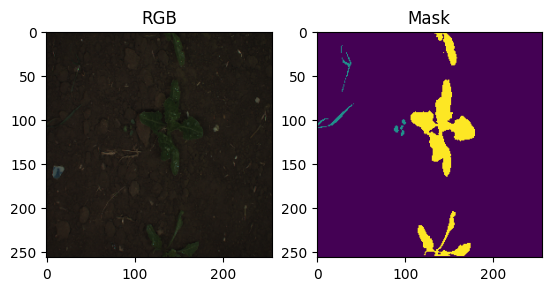

In [12]:
plt.subplot(1,2,1)
plt.imshow(img[:3].permute(1,2,0))
plt.title("RGB")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Mask")

In [13]:
import torch
print(torch.unique(mask))

tensor([0, 1, 2])


In [14]:
train_dataset = WeedDataset(
    ".",
    "train.txt"
)

test_dataset = WeedDataset(
    ".",
    "test.txt"
)

In [15]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

In [16]:
imgs, masks = next(iter(train_loader))
print(imgs.shape)
print(masks.shape)

torch.Size([8, 4, 256, 256])
torch.Size([8, 256, 256])


In [17]:
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=4, num_classes=3):
        super().__init__()

        self.down1 = DoubleConv(in_channels,64)
        self.pool = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64,128)
        self.down3 = DoubleConv(128,256)

        self.up1 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.conv1 = DoubleConv(256,128)

        self.up2 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.conv2 = DoubleConv(128,64)

        self.final = nn.Conv2d(64,num_classes,1)

    def forward(self,x):

        d1 = self.down1(x)
        d2 = self.down2(self.pool(d1))
        d3 = self.down3(self.pool(d2))

        u1 = self.up1(d3)
        u1 = torch.cat([u1,d2],dim=1)
        u1 = self.conv1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2,d1],dim=1)
        u2 = self.conv2(u2)

        return self.final(u2)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
epochs = 10

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch:",epoch,"Loss:", total_loss/len(train_loader))

Epoch: 0 Loss: 0.8816338633668834
Epoch: 1 Loss: 0.316158193966438
Epoch: 2 Loss: 0.24802080156474277
Epoch: 3 Loss: 0.16040927094632182
Epoch: 4 Loss: 0.12274157744029472
Epoch: 5 Loss: 0.10222463566681435
Epoch: 6 Loss: 0.08629961992646086
Epoch: 7 Loss: 0.0808756501767142
Epoch: 8 Loss: 0.07834815863391449
Epoch: 9 Loss: 0.07308045646239972


In [19]:
def pixel_accuracy(pred, mask):

    pred = torch.argmax(pred, dim=1)

    correct = (pred == mask).sum()
    total = mask.numel()

    return correct.float() / total

In [20]:
def compute_iou(pred, mask, num_classes=3):

    pred = torch.argmax(pred,1)

    ious = []

    for cls in range(num_classes):

        pred_inds = (pred==cls)
        target_inds = (mask==cls)

        intersection = (pred_inds & target_inds).sum()
        union = (pred_inds | target_inds).sum()

        if union == 0:
            continue

        ious.append(intersection.float()/union.float())

    return torch.mean(torch.tensor(ious))

In [21]:
model.eval()

accs=[]
ious=[]

with torch.no_grad():

    for images,masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        accs.append(pixel_accuracy(preds,masks))
        ious.append(compute_iou(preds,masks))

print("Pixel Acc:", torch.mean(torch.tensor(accs)))
print("IoU:", torch.mean(torch.tensor(ious)))

Pixel Acc: tensor(0.9436)
IoU: tensor(0.3145)


In [22]:
from sklearn.metrics import f1_score

def compute_f1(pred, mask):

    pred = torch.argmax(pred,1)

    pred = pred.cpu().numpy().flatten()
    mask = mask.cpu().numpy().flatten()

    return f1_score(mask, pred, average="macro")

In [23]:
model.eval()

accs=[]
ious=[]
f1s=[]

with torch.no_grad():

    for images,masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        accs.append(pixel_accuracy(preds,masks))
        ious.append(compute_iou(preds,masks))
        f1s.append(compute_f1(preds,masks))

print("Pixel Accuracy:", torch.mean(torch.tensor(accs)))
print("IoU:", torch.mean(torch.tensor(ious)))
print("F1:", sum(f1s)/len(f1s))

Pixel Accuracy: tensor(0.9436)
IoU: tensor(0.3145)
F1: 0.32366011611750506


Text(0.5, 1.0, 'Prediction')

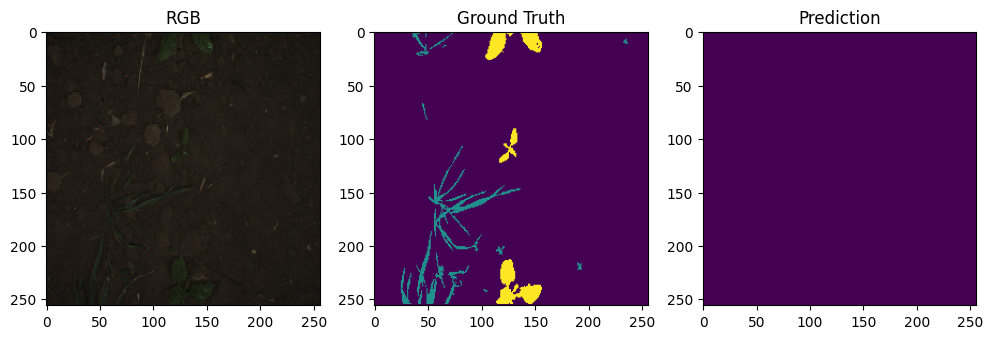

In [24]:
images, masks = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():
    preds = model(images)

preds = torch.argmax(preds,1).cpu()

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(images[0][:3].cpu().permute(1,2,0))
plt.title("RGB")

plt.subplot(1,3,2)
plt.imshow(masks[0])
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(preds[0])
plt.title("Prediction")

In [ ]:
torch.save(model.state_dict(), "baseline_model.pth")

In [3]:
!unzip sugar_beets_2016.zip

Archive:  sugar_beets_2016.zip
   creating: annotations/
  inflating: annotations/100.png     
  inflating: annotations/101.png     
  inflating: annotations/102.png     
  inflating: annotations/103.png     
  inflating: annotations/104.png     
  inflating: annotations/105.png     
  inflating: annotations/106.png     
  inflating: annotations/107.png     
  inflating: annotations/108.png     
  inflating: annotations/109.png     
  inflating: annotations/110.png     
  inflating: annotations/111.png     
  inflating: annotations/112.png     
  inflating: annotations/113.png     
  inflating: annotations/114.png     
  inflating: annotations/115.png     
  inflating: annotations/116.png     
  inflating: annotations/117.png     
  inflating: annotations/118.png     
  inflating: annotations/119.png     
  inflating: annotations/120.png     
  inflating: annotations/121.png     
  inflating: annotations/122.png     
  inflating: annotations/123.png     
  inflating: annotations/124.pn

In [25]:
model = UNet().to(device)

model.load_state_dict(torch.load("baseline_model.pth", map_location=device))

model.eval()

UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (down3): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (up1): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2))
  (conv1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(256, 128, kernel_size=(3, 3

In [26]:
model.eval()

accs=[]
ious=[]

with torch.no_grad():

    for images,masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        accs.append(pixel_accuracy(preds,masks))
        ious.append(compute_iou(preds,masks))

print("Pixel Acc:", torch.mean(torch.tensor(accs)))
print("IoU:", torch.mean(torch.tensor(ious)))

Pixel Acc: tensor(0.9756)
IoU: tensor(0.5779)


In [27]:
baseline_pixel = float(torch.mean(torch.tensor(accs)))
baseline_iou = float(torch.mean(torch.tensor(ious)))

print(baseline_pixel, baseline_iou)

0.9756259918212891 0.5778909921646118


In [29]:
!pip install albumentations

In [30]:
import albumentations as A


In [31]:
augmentations = {

    "none": None,

    "hflip": A.Compose([
        A.HorizontalFlip(p=1)
    ]),

    "vflip": A.Compose([
        A.VerticalFlip(p=1)
    ]),

    "rotation": A.Compose([
        A.Rotate(limit=30, p=1)
    ]),

    "brightness": A.Compose([
        A.RandomBrightnessContrast(p=1)
    ]),

    "noise": A.Compose([
        A.GaussNoise(p=1)
    ])
}

In [33]:
def train_model(transform):

    train_dataset = WeedDataset(".", "train.txt", transform)
    train_loader  = DataLoader(train_dataset, batch_size=8, shuffle=True)

    model = UNet().to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    for epoch in range(5):

        model.train()

        for images, masks in train_loader:

            images = images.to(device)
            masks  = masks.to(device)

            preds = model(images)

            loss = criterion(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return model

In [36]:
results = {}

for name, aug in augmentations.items():

    print("Running:", name)

    model = train_model(aug)

    model.eval()

    accs=[]
    ious=[]

    with torch.no_grad():

        for images, masks in test_loader:

            images = images.to(device)
            masks  = masks.to(device)

            preds = model(images)

            accs.append(pixel_accuracy(preds, masks))
            ious.append(compute_iou(preds, masks))

    results[name] = (
        float(torch.mean(torch.tensor(accs))),
        float(torch.mean(torch.tensor(ious)))
    )

print(results)

Running: none
Running: hflip
Running: vflip
Running: rotation
Running: brightness
Running: noise
{'none': (0.9709502458572388, 0.5415711998939514), 'hflip': (0.9456863403320312, 0.33731609582901), 'vflip': (0.9710112810134888, 0.5412850975990295), 'rotation': (0.9684810638427734, 0.5215640664100647), 'brightness': (0.9666241407394409, 0.5103232860565186), 'noise': (0.9436408281326294, 0.3145469129085541)}


In [37]:
#training function that accepts optimizer and learning rate for hyper-parameter
def train_model(transform=None, lr=1e-4, optimizer_name="adam"):

    train_dataset = WeedDataset(".", "train.txt", transform)
    train_loader  = DataLoader(train_dataset, batch_size=8, shuffle=True)

    model = UNet().to(device)

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    for epoch in range(5):

        model.train()

        for images, masks in train_loader:

            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)

            loss = criterion(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return model

In [38]:
hyper_results = {}

experiments = {
    "baseline": ("adam", 1e-4),
    "lr_high": ("adam", 5e-4),
    "lr_low": ("adam", 5e-5),
    "sgd": ("sgd", 0.01)
}

for name, (opt, lr) in experiments.items():

    print("Running:", name)

    model = train_model(None, lr, opt)

    model.eval()

    accs=[]
    ious=[]

    with torch.no_grad():

        for images, masks in test_loader:

            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)

            accs.append(pixel_accuracy(preds,masks))
            ious.append(compute_iou(preds,masks))

    hyper_results[name] = (
        float(torch.mean(torch.tensor(accs))),
        float(torch.mean(torch.tensor(ious)))
    )

print(hyper_results)

Running: baseline
Running: lr_high
Running: lr_low
Running: sgd
{'baseline': (0.9686669111251831, 0.5246425271034241), 'lr_high': (0.9756752848625183, 0.5989946722984314), 'lr_low': (0.9436408281326294, 0.3145469129085541), 'sgd': (0.9436408281326294, 0.3145469129085541)}


Text(0.5, 1.0, 'Prediction')

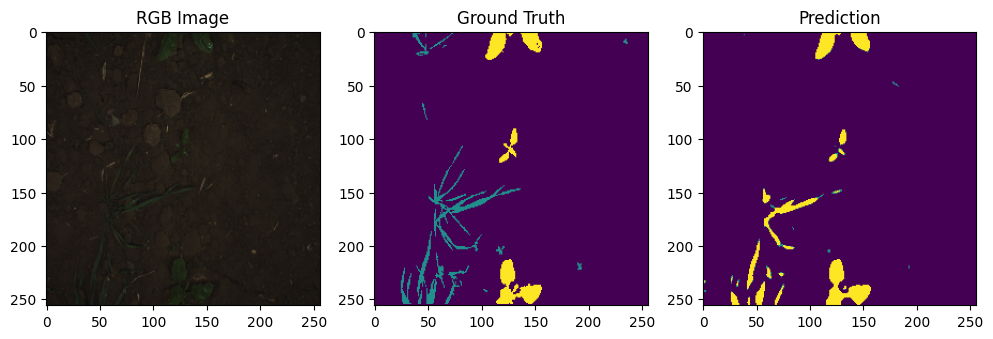

In [46]:
model.eval()

images, masks = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():
    preds = model(images)

preds = torch.argmax(preds, dim=1).cpu()

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(images[0][:3].permute(1,2,0).cpu())
plt.title("RGB Image")

plt.subplot(1,3,2)
plt.imshow(masks[0])
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(preds[0])
plt.title("Prediction")

In [40]:
#training function with seed
def train_with_seed(seed):

    torch.manual_seed(seed)

    train_dataset = WeedDataset(".", "train.txt", None)
    train_loader  = DataLoader(train_dataset, batch_size=8, shuffle=True)

    model = UNet().to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

    for epoch in range(5):

        model.train()

        for images, masks in train_loader:

            images = images.to(device)
            masks  = masks.to(device)

            preds = model(images)

            loss = criterion(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return model

In [41]:
seed_results = []

for seed in [0,1,2,3,4]:

    print("Seed:", seed)

    model = train_with_seed(seed)

    model.eval()

    ious=[]

    with torch.no_grad():

        for images,masks in test_loader:

            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)

            ious.append(compute_iou(preds,masks))

    seed_results.append(float(torch.mean(torch.tensor(ious))))

print(seed_results)

Seed: 0
Seed: 1
Seed: 2
Seed: 3
Seed: 4
[0.5950045585632324, 0.5861515402793884, 0.5753595232963562, 0.5845369696617126, 0.5793679356575012]


In [42]:
import numpy as np

print("Mean IoU:", np.mean(seed_results))
print("Std IoU:", np.std(seed_results))

Mean IoU: 0.5840841054916381
Std IoU: 0.006664776969016802


Text(0.5, 1.0, 'Prediction')

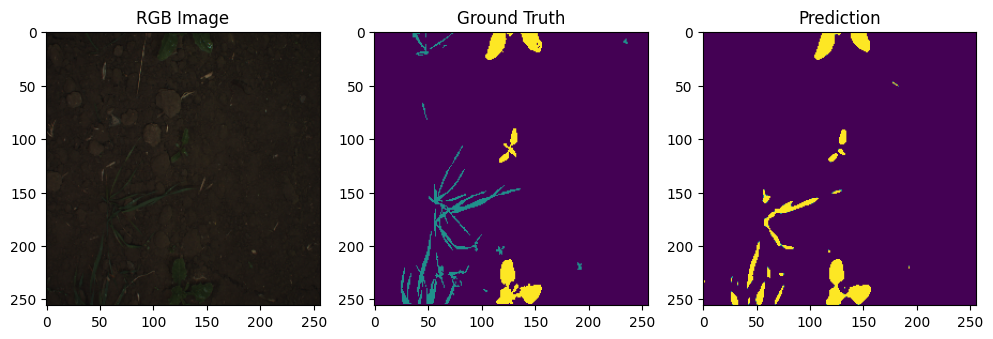

In [43]:
model.eval()

images, masks = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():
    preds = model(images)

preds = torch.argmax(preds, dim=1).cpu()

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(images[0][:3].permute(1,2,0).cpu())
plt.title("RGB Image")

plt.subplot(1,3,2)
plt.imshow(masks[0])
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(preds[0])
plt.title("Prediction")